# T1 ContFlux Loop Repeated — Analysis

Load and plot data from `t1_cont_flux_repeated_qubit*.h5` and associated CSVs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import h5py

from slab_qick_calib.experiments.flux.t1_cont_flux import T1ContFluxRepeated
from slab_qick_calib.helpers import handy
%matplotlib inline
handy.config_figs()

DATA_DIR = Path("C:/_Data/sample_50_new/data")
H5_FILE = DATA_DIR / "t1_cont_flux_repeated_qubit2_00007.h5"
CSV_DIR = DATA_DIR / "t1_cont_flux_repeated_qubit2_00007" / "csvs"

<module 'slab_qick_calib.experiments' from 'C:\\_Lib\\python\\qq\\slab_qick_calib\\experiments\\__init__.py'>
C:\_Lib\python\qq\slab_qick_calib\experiments
imported slab_qick_calib.experiments.general.qick_experiment
imported slab_qick_calib.experiments.general.qick_experiment_2q
imported slab_qick_calib.experiments.general.qick_program
C:\_Lib\python\qq\slab_qick_calib\experiments\flux
imported slab_qick_calib.experiments.flux.pulse_probe_spectroscopy_flux
imported slab_qick_calib.experiments.flux.rabi_flux
imported slab_qick_calib.experiments.flux.single_shot_flux
imported slab_qick_calib.experiments.flux.t1_cont_flux
imported slab_qick_calib.experiments.flux.t1_fastflux_loop
C:\_Lib\python\qq\slab_qick_calib\experiments\general
C:\_Lib\python\qq\slab_qick_calib\experiments\single_qubit
imported slab_qick_calib.experiments.single_qubit.active_reset
imported slab_qick_calib.experiments.single_qubit.power_calibration
imported slab_qick_calib.experiments.single_qubit.pulse_probe_spectro

## 1. Load HDF5 and display built-in plots

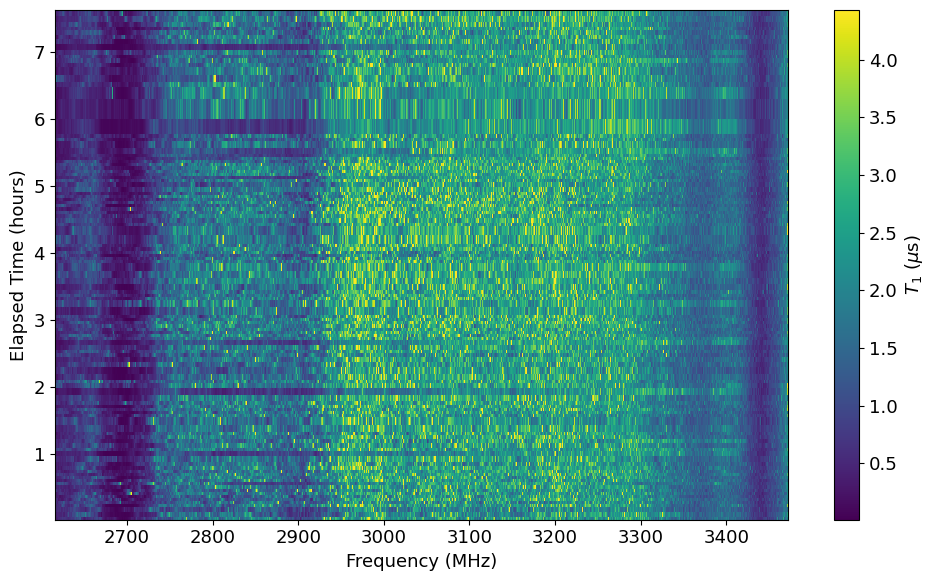

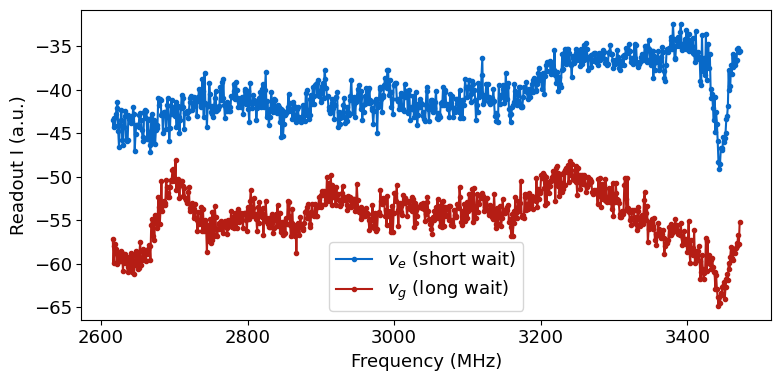

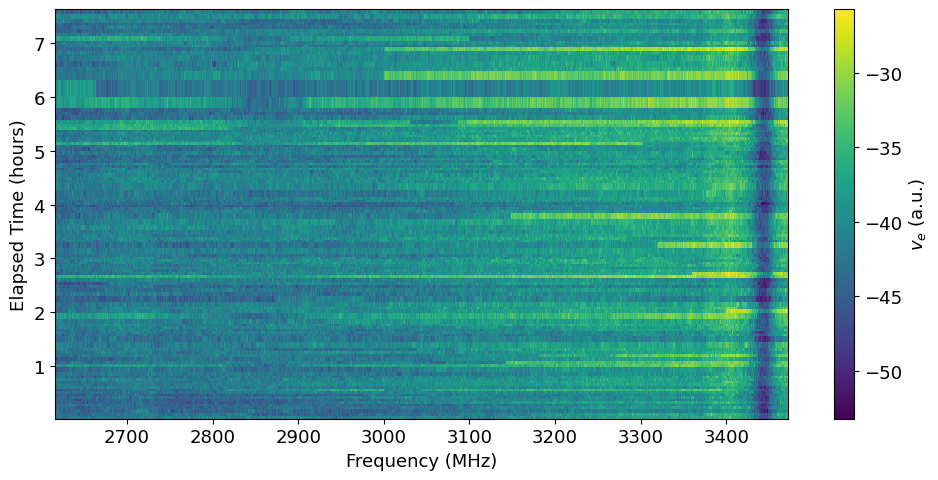

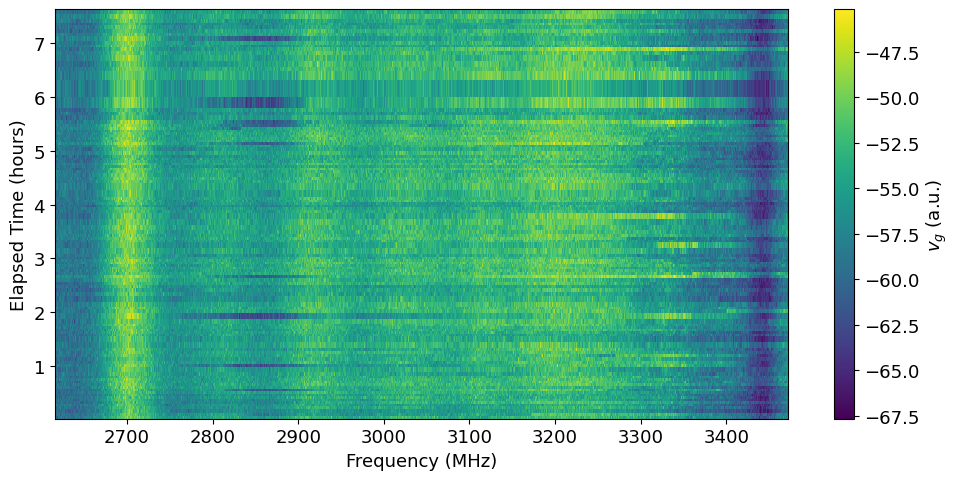

In [2]:
import time

    
expt = T1ContFluxRepeated.from_h5file(str(H5_FILE))
expt.display()
    

## 2. Inspect HDF5 contents

In [3]:
with h5py.File(H5_FILE, "r") as f:
    print("Datasets:")
    for key in f.keys():
        ds = f[key]
        print(f"  {key}: shape={ds.shape}, dtype={ds.dtype}")
    print(f"\nAttributes: {list(f.attrs.keys())[:10]}...")

data = expt.data
t1_list = data["t1_list"]
freq_pts = data["freq_pts"]
gain_pts = data["gain_pts"]
timestamps = data["timestamps"]
print(f"\nt1_list: {t1_list.shape} ({t1_list.shape[0]} sweeps x {t1_list.shape[1]} freq/gain pts)")
print(f"Time span: {timestamps[0]:.2f} \u2014 {timestamps[-1]:.2f} hours")

Datasets:
  amps: shape=(111, 800), dtype=float64
  avgi: shape=(111, 800), dtype=float64
  avgq: shape=(111, 800), dtype=float64
  freq_pts: shape=(800,), dtype=float64
  gain_pts: shape=(800,), dtype=float64
  phases: shape=(111, 800), dtype=float64
  population: shape=(111, 800), dtype=float64
  t1_list: shape=(111, 800), dtype=float64
  timestamps: shape=(111,), dtype=float64
  ve_list: shape=(111, 800), dtype=float64
  vg_list: shape=(111, 800), dtype=float64
  wait_times: shape=(111, 800), dtype=float64

Attributes: ['config']...

t1_list: (111, 800) (111 sweeps x 800 freq/gain pts)
Time span: 0.05 — 7.59 hours


In [4]:
# Optional: narrow the frequency range for all downstream analysis
# Set to None to use the full range
FREQ_MIN = None  # e.g. 3440
FREQ_MAX = None  # e.g. 3460

if FREQ_MIN is not None or FREQ_MAX is not None:
    lo = FREQ_MIN if FREQ_MIN is not None else freq_pts.min()
    hi = FREQ_MAX if FREQ_MAX is not None else freq_pts.max()
    freq_mask = (freq_pts >= lo) & (freq_pts <= hi)
    freq_pts = freq_pts[freq_mask]
    gain_pts = gain_pts[freq_mask]
    t1_list = t1_list[:, freq_mask]
    print(f"Narrowed to {lo}\u2013{hi} MHz: {freq_mask.sum()} / {len(freq_mask)} points")
else:
    print(f"Using full frequency range: {freq_pts.min():.1f}\u2013{freq_pts.max():.1f} MHz ({len(freq_pts)} points)")

Using full frequency range: 2616.1–3471.3 MHz (800 points)


In [5]:
# Filter out bad sweeps where calibration jumped and T1 is large across the whole line
median_per_sweep = np.nanmedian(t1_list, axis=1)
global_median = np.nanmedian(median_per_sweep)
global_iqr = np.subtract(*np.nanpercentile(median_per_sweep, [75, 25]))
threshold = global_median + 3 * global_iqr

bad_mask = median_per_sweep > threshold
n_bad = bad_mask.sum()
print(f"Median T1 per sweep: median={global_median:.2f}, IQR={global_iqr:.2f}, threshold={threshold:.2f}")
print(f"Flagged {n_bad}/{len(median_per_sweep)} sweeps as bad (median T1 > {threshold:.2f} \u00b5s)")
if n_bad > 0:
    print(f"  Bad sweep indices: {np.where(bad_mask)[0]}")
    print(f"  Their median T1 values: {median_per_sweep[bad_mask]}")
    t1_list[bad_mask] = np.nan

Median T1 per sweep: median=1.90, IQR=0.20, threshold=2.50
Flagged 0/111 sweeps as bad (median T1 > 2.50 µs)


## 3. T1 heatmap with robust color scale

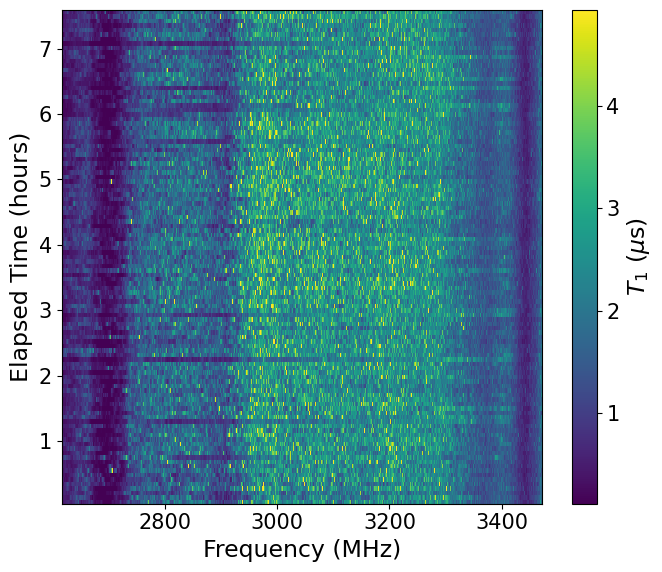

In [6]:
rc = {
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 17,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "figure.titlesize": 18,
    "lines.linewidth": 3,
    "lines.markersize": 8,
}
plt.rcParams.update(rc)
# T1 heatmap with percentile-based clipping; NaN rows shown in grey
finite = t1_list[np.isfinite(t1_list)]
vmin, vmax = np.percentile(finite, [1, 99.5])

cmap = plt.cm.viridis.copy()
cmap.set_bad(color="0.45")  # dark grey for NaN

# freq_pts goes high-to-low; flip data so column 0 = lowest freq (left edge)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(t1_list[:, ::-1], aspect="auto", origin="lower", cmap=cmap,
               vmin=vmin, vmax=vmax, interpolation="nearest",
               extent=[freq_pts[-1], freq_pts[0], timestamps[0], timestamps[-1]])
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Elapsed Time (hours)")
plt.colorbar(im, ax=ax, label="$T_1$ ($\\mu$s)")
plt.tight_layout()
plt.show()

C:\Users\circu\AppData\Local\Temp\ipykernel_13604\1619849528.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


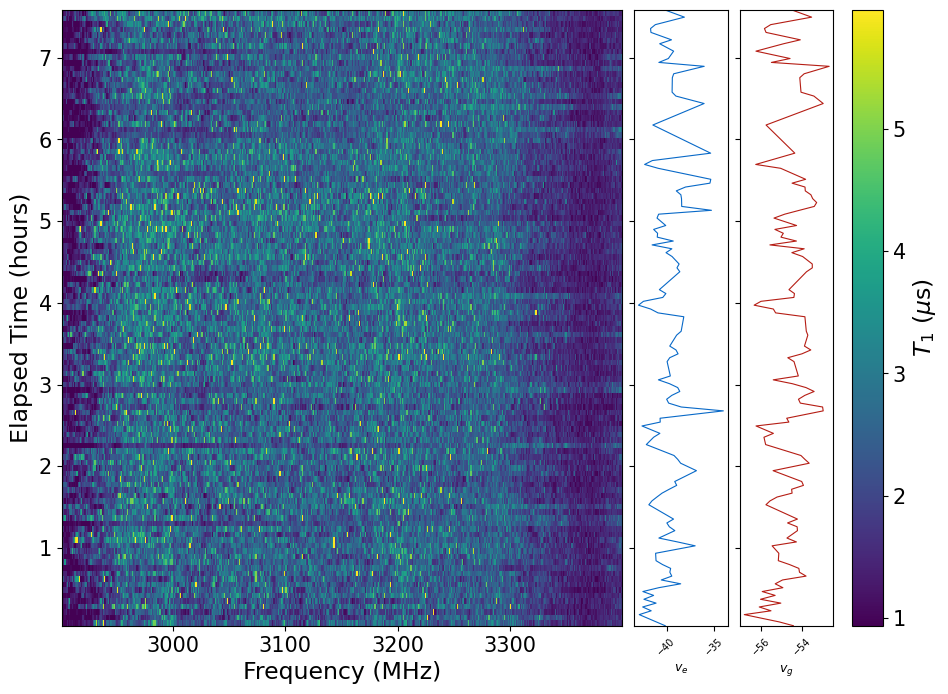

In [7]:
# Zoomed T1 heatmap with ve/vg calibration alongside — select frequency range here
freq_min = 2900  # MHz
freq_max = 3400  # MHz

mask = (freq_pts >= freq_min) & (freq_pts <= freq_max)
freq_sub = freq_pts[mask]

t1_sub = t1_list[:, mask]
finite_sub = t1_sub[np.isfinite(t1_sub)]
vmin_z, vmax_z = np.percentile(finite_sub, [1, 99.75]) if len(finite_sub) > 0 else (0, 1)

cmap_z = plt.cm.viridis.copy()
cmap_z.set_bad(color="0.45")

# Load per-point calibration data (2D: sweeps x gain_pts)
_ve_2d = data["ve_list"]
_vg_2d = data["vg_list"]
# Average ve/vg across all gain points per sweep to get a 1D time trace
cal_ve = np.nanmean(_ve_2d, axis=1)
cal_vg = np.nanmean(_vg_2d, axis=1)
cal_times = timestamps[:len(cal_ve)]

fig, axes = plt.subplots(1, 3, figsize=(12, 8), sharey=True,
                         gridspec_kw={"width_ratios": [6, 1, 1], "wspace": 0.05})

# T1 heatmap
ax = axes[0]
im = ax.imshow(t1_sub[:, ::-1], aspect="auto", origin="lower", cmap=cmap_z,
               vmin=vmin_z, vmax=vmax_z, interpolation="nearest",
               extent=[freq_sub[-1], freq_sub[0], timestamps[0], timestamps[-1]])
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Elapsed Time (hours)")

# ve vs time (averaged across gain points)
ax = axes[1]
ax.plot(cal_ve, cal_times, "-", lw=0.8, color="C0")
ax.set_xlabel("$v_e$", fontsize=9)
ax.tick_params(axis="x", labelsize=7, rotation=45)

# vg vs time (averaged across gain points)
ax = axes[2]
ax.plot(cal_vg, cal_times, "-", lw=0.8, color="C1")
ax.set_xlabel("$v_g$", fontsize=9)
ax.tick_params(axis="x", labelsize=7, rotation=45)

plt.colorbar(im, ax=axes.tolist(), label="$T_1$ ($\\mu$s)", pad=0.02)
plt.tight_layout()
plt.show()

## 4. Mean T1 vs frequency (time-averaged)

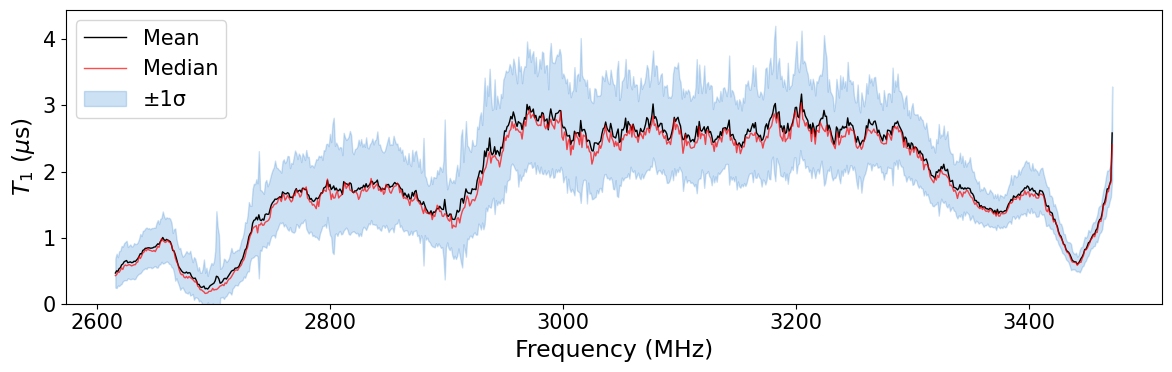

In [8]:
# Time-averaged T1 vs frequency with std band
mean_t1 = np.nanmean(t1_list, axis=0)
std_t1 = np.nanstd(t1_list, axis=0)
median_t1 = np.nanmedian(t1_list, axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(freq_pts, mean_t1, "k-", lw=1, label="Mean")
ax.plot(freq_pts, median_t1, "r-", lw=1, alpha=0.7, label="Median")
ax.fill_between(freq_pts, mean_t1 - std_t1, mean_t1 + std_t1, alpha=0.2, color="C0", label="\u00b11\u03c3")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("$T_1$ ($\\mu$s)")
ax.legend()
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

## 5. T1 time trace at selected frequencies

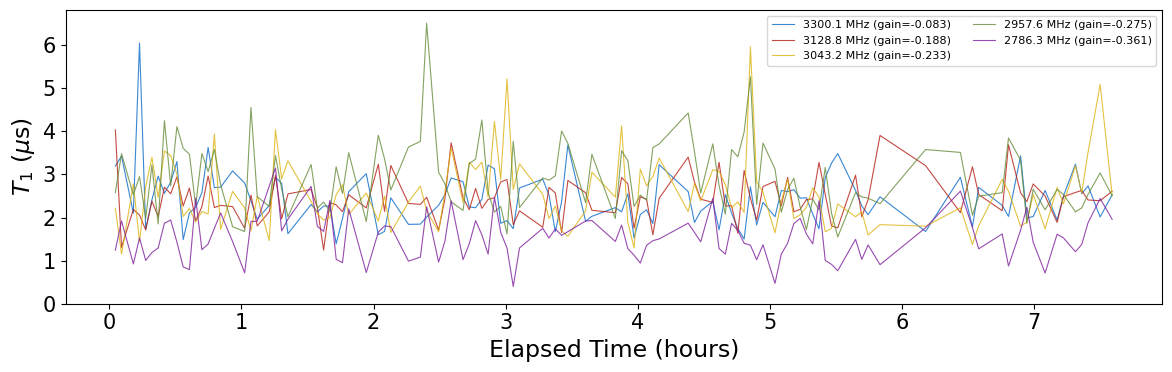

In [9]:
# Pick a few frequency indices to track T1 over time
n_freq = len(freq_pts)
idx_list = [n_freq // 5, 2 * n_freq // 5, n_freq // 2, 3 * n_freq // 5, 4 * n_freq // 5]

fig, ax = plt.subplots(figsize=(12, 4))
for idx in idx_list:
    ax.plot(timestamps, t1_list[:, idx], lw=0.8, alpha=0.8,
            label=f"{freq_pts[idx]:.1f} MHz (gain={gain_pts[idx]:.3f})")
ax.set_xlabel("Elapsed Time (hours)")
ax.set_ylabel("$T_1$ ($\\mu$s)")
ax.legend(fontsize=8, ncol=2)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

## 6. Calibration drift (ve/vg) — per-point inline calibration

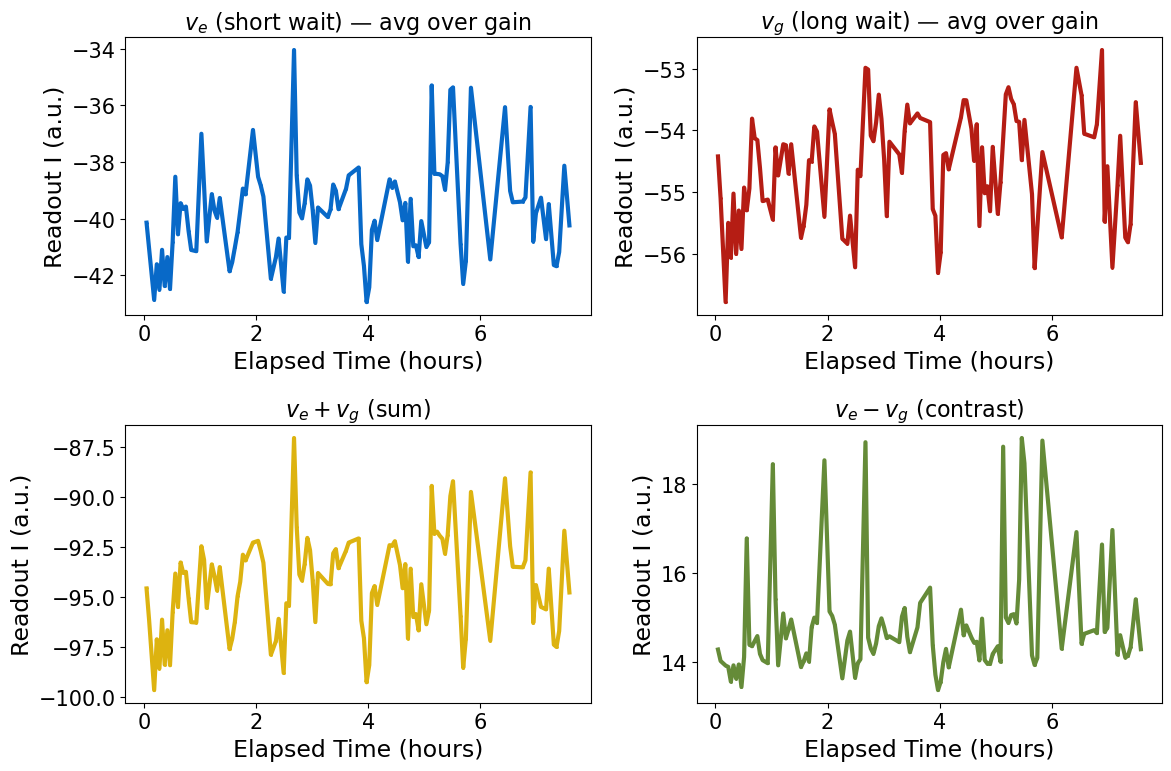

In [10]:
ve_2d = data["ve_list"]
vg_2d = data["vg_list"]

# Average across gain points to get a 1D time trace
ve_mean = np.nanmean(ve_2d, axis=1)
vg_mean = np.nanmean(vg_2d, axis=1)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ve vs time
ax = axes[0, 0]
ax.plot(timestamps, ve_mean, ".-", ms=2, color="C0")
ax.set_xlabel("Elapsed Time (hours)")
ax.set_ylabel("Readout I (a.u.)")
ax.set_title("$v_e$ (short wait) — avg over gain")

# vg vs time
ax = axes[0, 1]
ax.plot(timestamps, vg_mean, ".-", ms=2, color="C1")
ax.set_xlabel("Elapsed Time (hours)")
ax.set_ylabel("Readout I (a.u.)")
ax.set_title("$v_g$ (long wait) — avg over gain")

# ve + vg (sum) vs time
ax = axes[1, 0]
ax.plot(timestamps, ve_mean + vg_mean, ".-", ms=2, color="C2")
ax.set_xlabel("Elapsed Time (hours)")
ax.set_ylabel("Readout I (a.u.)")
ax.set_title("$v_e + v_g$ (sum)")

# ve - vg (contrast) vs time
ax = axes[1, 1]
ax.plot(timestamps, ve_mean - vg_mean, ".-", ms=2, color="C3")
ax.set_xlabel("Elapsed Time (hours)")
ax.set_ylabel("Readout I (a.u.)")
ax.set_title("$v_e - v_g$ (contrast)")

plt.tight_layout()
plt.show()

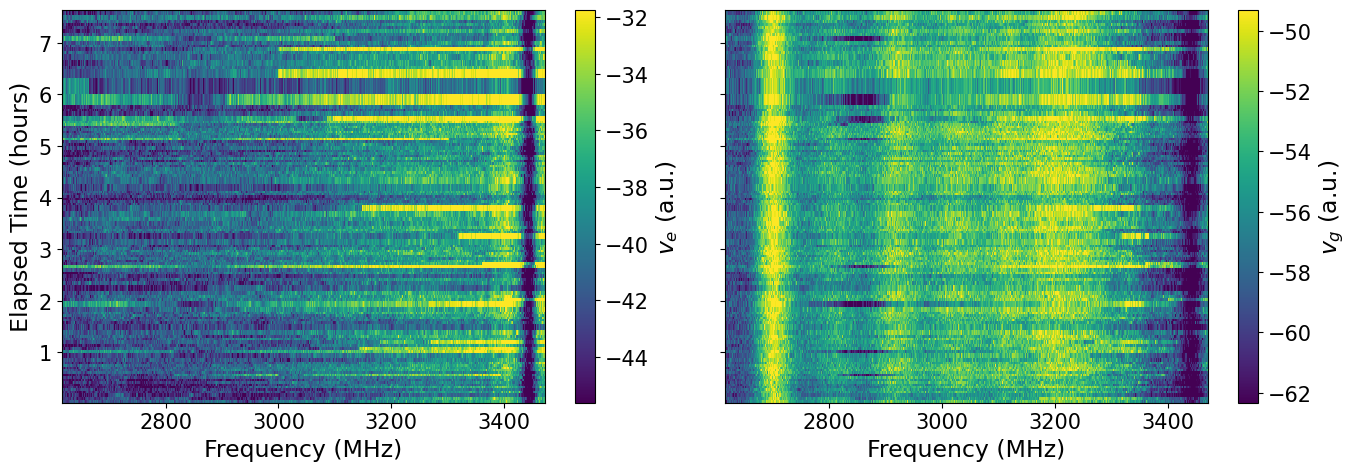

In [11]:
# ve/vg heatmaps vs frequency and time
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, arr, label in [(axes[0], ve_2d, "$v_e$"), (axes[1], vg_2d, "$v_g$")]:
    # Apply freq mask if narrowed
    if arr.shape[1] != len(freq_pts):
        _all_freq = data["freq_pts"]
        _mask = (_all_freq >= freq_pts.min()) & (_all_freq <= freq_pts.max())
        arr = arr[:, _mask]
    finite_arr = arr[np.isfinite(arr)]
    if len(finite_arr) > 0:
        v0, v1 = np.percentile(finite_arr, [2, 98])
    else:
        v0, v1 = 0, 1
    mesh = ax.pcolormesh(freq_pts, timestamps[:len(arr)], arr, cmap="viridis",
                         shading="auto", vmin=v0, vmax=v1, rasterized=True)
    ax.set_xlabel("Frequency (MHz)")
    plt.colorbar(mesh, ax=ax, label=f"{label} (a.u.)")

axes[0].set_ylabel("Elapsed Time (hours)")
plt.tight_layout()
plt.show()

## 7. Load and explore CSV sweep data

In [12]:
# Load all CSVs into a single DataFrame
csv_files = sorted(CSV_DIR.glob("sweep_*.csv"))
print(f"Found {len(csv_files)} CSV files in {CSV_DIR}")

dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    # Extract sweep index from filename
    df["sweep"] = int(f.stem.split("_")[1])
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all["timestamp"] = pd.to_datetime(df_all["timestamp"], format="ISO8601")

# Apply same frequency filter as HDF5 data
if FREQ_MIN is not None or FREQ_MAX is not None:
    lo = FREQ_MIN if FREQ_MIN is not None else df_all["freq"].min()
    hi = FREQ_MAX if FREQ_MAX is not None else df_all["freq"].max()
    n_before_freq = len(df_all)
    df_all = df_all[(df_all["freq"] >= lo) & (df_all["freq"] <= hi)]
    print(f"Frequency filter {lo}\u2013{hi} MHz: kept {len(df_all)}/{n_before_freq} rows")

# Filter out bad sweeps (same logic as HDF5 filtering)
csv_median_per_sweep = df_all.groupby("sweep")["t1"].median()
csv_global_median = csv_median_per_sweep.median()
csv_global_iqr = csv_median_per_sweep.quantile(0.75) - csv_median_per_sweep.quantile(0.25)
csv_threshold = csv_global_median + 3 * csv_global_iqr
bad_sweeps = csv_median_per_sweep[csv_median_per_sweep > csv_threshold].index
n_before = df_all["sweep"].nunique()
n_rows_before = len(df_all)

# Print details of bad sweeps
t0_csv = df_all["timestamp"].min()
for s in bad_sweeps:
    sub = df_all[df_all["sweep"] == s]
    elapsed_h = (sub["timestamp"].iloc[0] - t0_csv).total_seconds() / 3600
    print(f"  Removing sweep {s}: {len(sub)} rows, elapsed={elapsed_h:.2f}h, median T1={csv_median_per_sweep[s]:.2f} \u00b5s")

df_all = df_all[~df_all["sweep"].isin(bad_sweeps)]
n_rows_removed = n_rows_before - len(df_all)
print(f"Filtered {len(bad_sweeps)}/{n_before} bad sweeps, removed {n_rows_removed} rows (threshold: median T1 > {csv_threshold:.2f} \u00b5s)")

print(f"Total rows: {len(df_all):,}")
print(f"Columns: {list(df_all.columns)}")
df_all.head()

Found 127 CSV files in C:\_Data\sample_50_new\data\t1_cont_flux_repeated_qubit2_00007\csvs
Filtered 0/127 bad sweeps, removed 0 rows (threshold: median T1 > 2.50 µs)
Total rows: 99,692
Columns: ['timestamp', 'gain', 'freq', 'wait_time', 'population', 't1', 've', 'vg', 'elapsed_s', 'sweep']


,timestamp,gain,freq,wait_time,population,t1,ve,vg,elapsed_s,sweep
0,2026-03-20 21:24:30.809824,0.150000,3471.321260,0.565000,0.754596,2.006589,-36.159084,-56.536892,0.180818,0
1,2026-03-20 21:24:31.004581,0.135462,3470.250935,1.003295,0.601198,1.971766,-35.132979,-57.198488,0.375575,0
2,2026-03-20 21:24:31.208702,0.127927,3469.180610,0.985883,0.545562,1.627032,-36.536682,-57.516567,0.579696,0
3,2026-03-20 21:24:31.408604,0.122093,3468.110286,0.813516,0.549275,1.357768,-38.166015,-57.062321,0.779598,0
4,2026-03-20 21:24:31.613941,0.117155,3467.039961,0.678884,0.786749,2.830505,-39.583976,-54.606487,0.984935,0


## 8. CSV-based plots: T1 distribution and wait_time adaptation

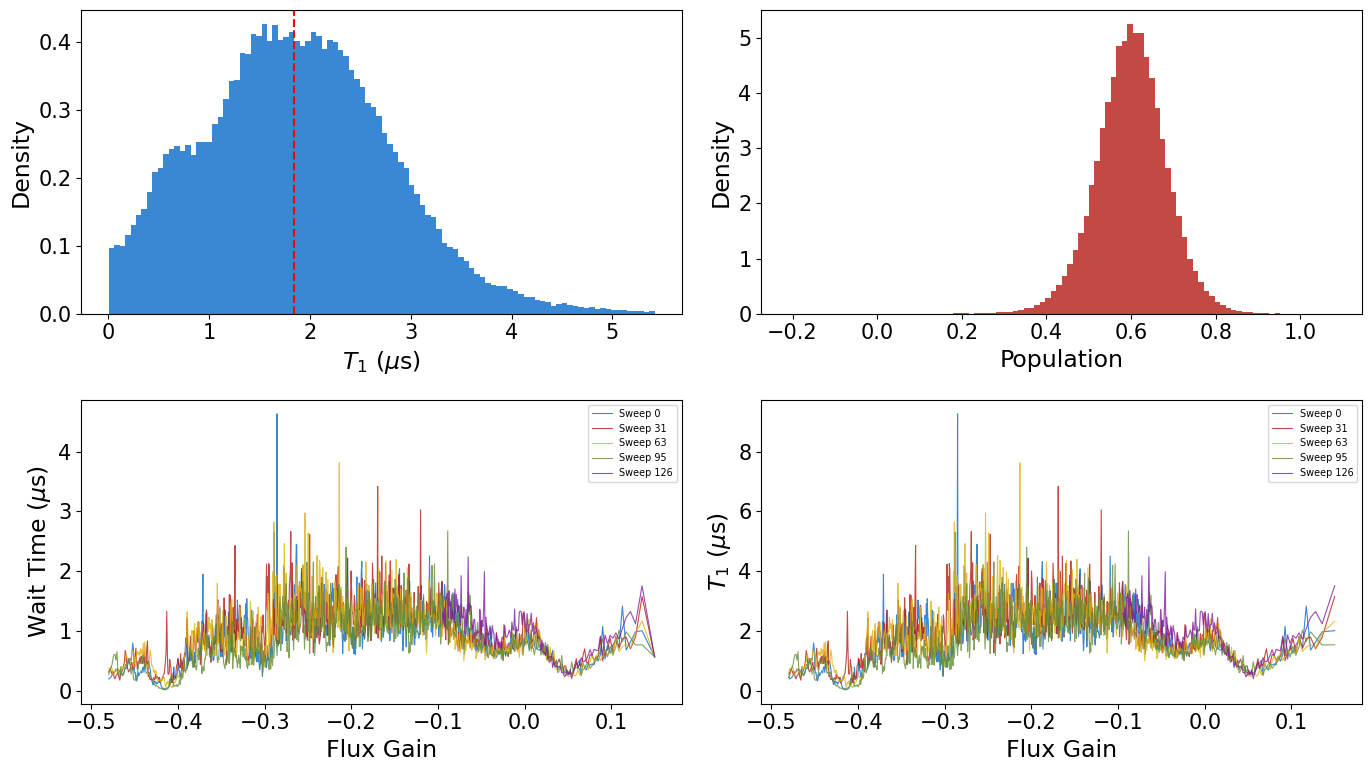

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# T1 histogram
ax = axes[0, 0]
valid_t1 = df_all["t1"].dropna()
valid_t1 = valid_t1[(valid_t1 > 0) & (valid_t1 < valid_t1.quantile(0.9975))]
ax.hist(valid_t1, bins=100, edgecolor="none", alpha=0.8, density=True)
ax.set_xlabel("$T_1$ ($\\mu$s)")
ax.set_ylabel("Density")
ax.axvline(valid_t1.median(), color="r", ls="--", lw=1.5)

# Population histogram
ax = axes[0, 1]
valid_pop = df_all["population"].dropna()
ax.hist(valid_pop, bins=100, edgecolor="none", alpha=0.8, color="C1", density=True)
ax.set_xlabel("Population")
ax.set_ylabel("Density")

# Wait time vs gain (colored by sweep)
ax = axes[1, 0]
sweep_ids = sorted(df_all["sweep"].unique())
for sweep_idx in [sweep_ids[0], sweep_ids[len(sweep_ids)//4], sweep_ids[len(sweep_ids)//2],
                  sweep_ids[3*len(sweep_ids)//4], sweep_ids[-1]]:
    sub = df_all[df_all["sweep"] == sweep_idx]
    if len(sub) > 0:
        ax.plot(sub["gain"], sub["wait_time"], lw=0.8, alpha=0.8, label=f"Sweep {sweep_idx}")
ax.set_xlabel("Flux Gain")
ax.set_ylabel("Wait Time ($\\mu$s)")
ax.legend(fontsize=7)

# T1 vs gain for a few sweeps
ax = axes[1, 1]
for sweep_idx in [sweep_ids[0], sweep_ids[len(sweep_ids)//4], sweep_ids[len(sweep_ids)//2],
                  sweep_ids[3*len(sweep_ids)//4], sweep_ids[-1]]:
    sub = df_all[df_all["sweep"] == sweep_idx]
    if len(sub) > 0:
        ax.plot(sub["gain"], sub["t1"], lw=0.8, alpha=0.8, label=f"Sweep {sweep_idx}")
ax.set_xlabel("Flux Gain")
ax.set_ylabel("$T_1$ ($\\mu$s)")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

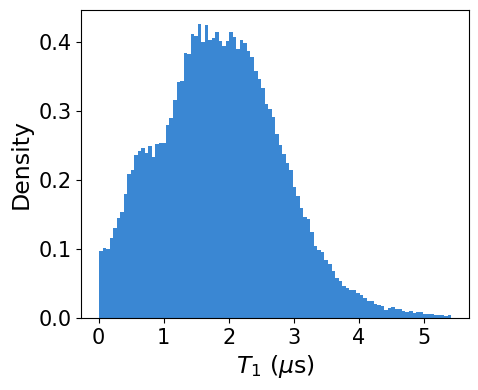

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
# T1 histogram
valid_t1 = df_all["t1"].dropna()
valid_t1 = valid_t1[(valid_t1 > 0) & (valid_t1 < valid_t1.quantile(0.9975))]
ax.hist(valid_t1, bins=100, edgecolor="none", alpha=0.8, density=True)
ax.set_xlabel("$T_1$ ($\\mu$s)")
ax.set_ylabel("Density")
plt.show()

## 9. T1 vs gain heatmap from CSVs (with absolute timestamps)

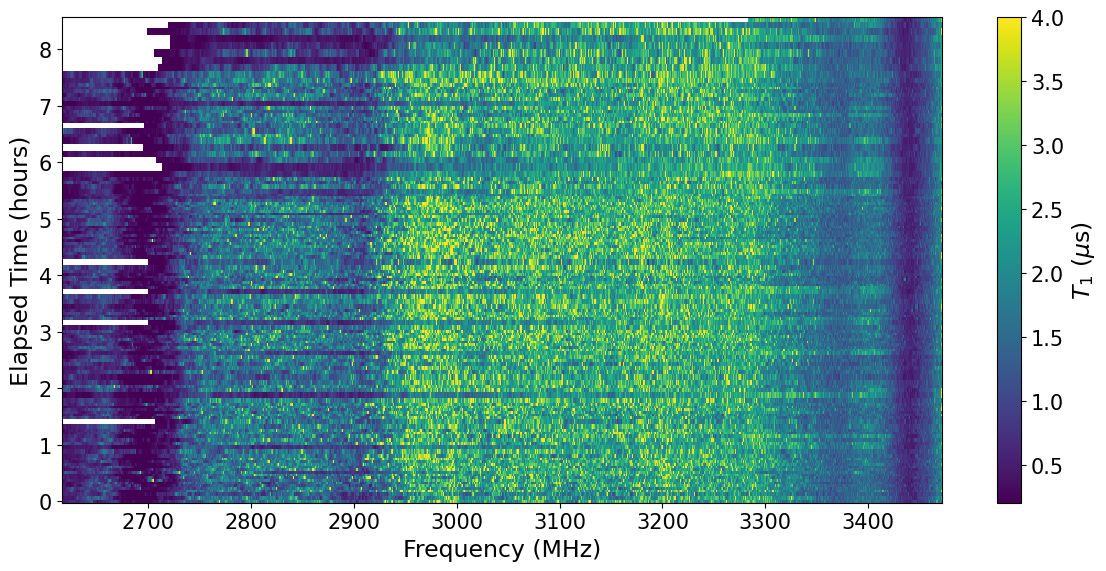

In [15]:
# Pivot CSV data into a 2D grid: sweep x freq -> T1
pivot = df_all.pivot_table(index="sweep", columns="freq", values="t1", aggfunc="first")
sweep_ids = pivot.index.values
freq_vals = pivot.columns.values
t1_grid = pivot.values

# Use absolute timestamps for y-axis (hours since first measurement)
t0 = df_all["timestamp"].min()
sweep_hours = df_all.groupby("sweep")["timestamp"].first().sort_index()
sweep_hours = (sweep_hours - t0).dt.total_seconds().values / 3600

finite = t1_grid[np.isfinite(t1_grid)]
vmin, vmax = np.percentile(finite, [2, 98])

fig, ax = plt.subplots(figsize=(12, 6))
mesh = ax.pcolormesh(freq_vals, sweep_hours[:len(t1_grid)], t1_grid,
                     cmap="viridis", shading="auto", vmin=vmin, vmax=vmax, rasterized=True)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Elapsed Time (hours)")
plt.colorbar(mesh, ax=ax, label="$T_1$ ($\\mu$s)")
plt.tight_layout()
plt.show()

## 10. avgi vs frequency vs time heatmap

Loaded avgi from H5: (111, 800)


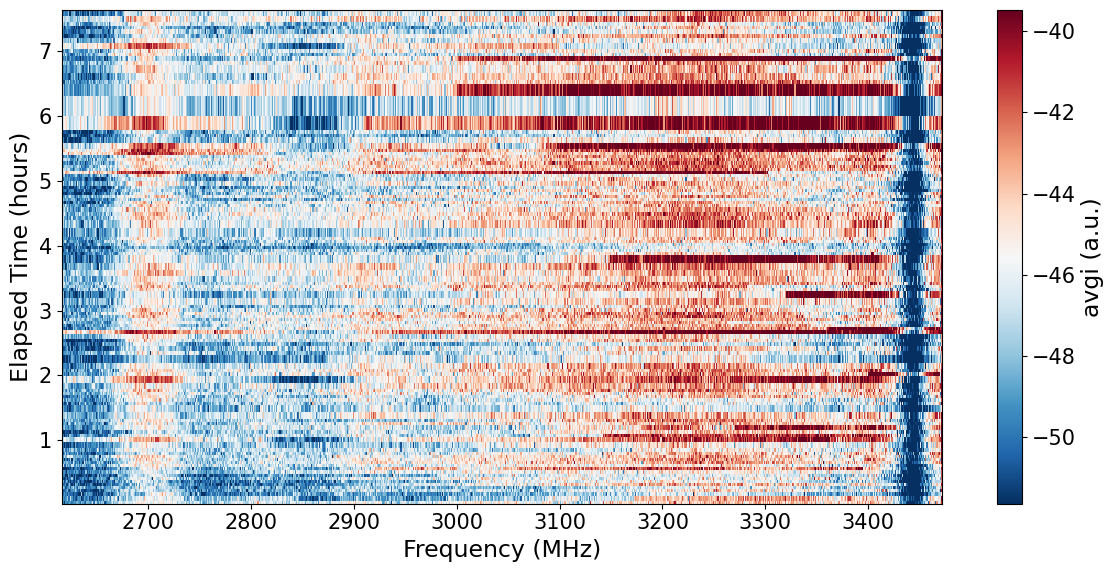

In [16]:
# Load avgi from H5
avgi_grid = data["avgi"]
_all_freq = data["freq_pts"]
if len(freq_pts) < len(_all_freq):
    _mask = (_all_freq >= freq_pts.min()) & (_all_freq <= freq_pts.max())
    avgi_grid = avgi_grid[:, _mask]
avgi_hours = timestamps[:len(avgi_grid)]
avgi_freqs = freq_pts
print(f"Loaded avgi from H5: {avgi_grid.shape}")

finite_avgi = avgi_grid[np.isfinite(avgi_grid)]
vmin_a, vmax_a = np.percentile(finite_avgi, [2, 98])

fig, ax = plt.subplots(figsize=(12, 6))
mesh = ax.pcolormesh(avgi_freqs, avgi_hours[:len(avgi_grid)], avgi_grid, cmap="RdBu_r",
                     shading="auto", vmin=vmin_a, vmax=vmax_a, rasterized=True)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Elapsed Time (hours)")
plt.colorbar(mesh, ax=ax, label="avgi (a.u.)")
plt.tight_layout()
plt.show()

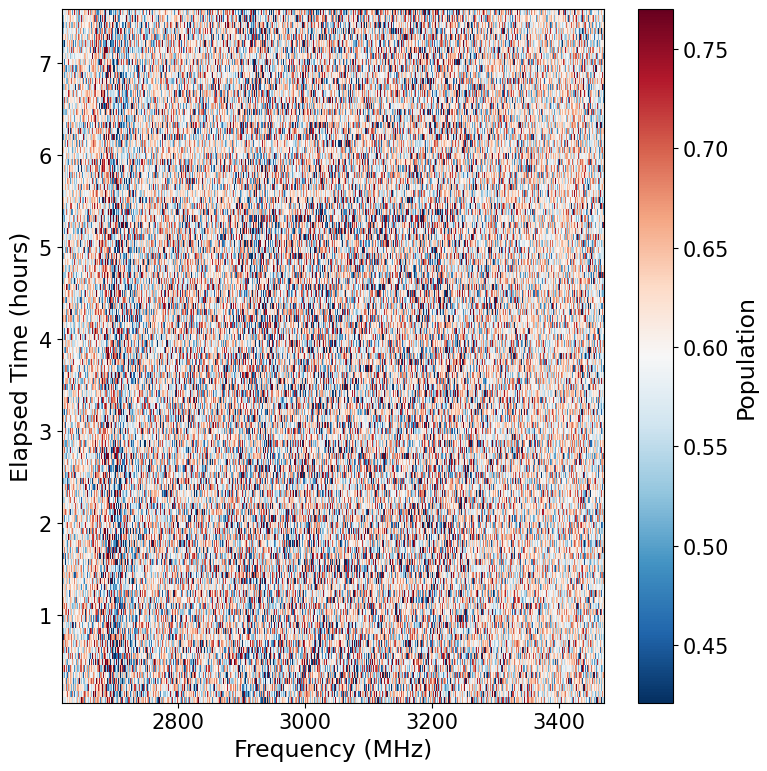

In [17]:
# Population heatmap (from H5)
pop_grid = data["population"]
_all_freq = data["freq_pts"]
if len(freq_pts) < len(_all_freq):
    _mask = (_all_freq >= freq_pts.min()) & (_all_freq <= freq_pts.max())
    pop_grid = pop_grid[:, _mask]

cmap_pop = plt.cm.RdBu_r.copy()
cmap_pop.set_bad(color="0.45")

finite_pop = pop_grid[np.isfinite(pop_grid)]
vmin_p, vmax_p = np.percentile(finite_pop, [2, 98])

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(pop_grid[:, ::-1], aspect="auto", origin="lower", cmap=cmap_pop,
               vmin=vmin_p, vmax=vmax_p, interpolation="nearest",
               extent=[freq_pts[-1], freq_pts[0], timestamps[0], timestamps[-1]])
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Elapsed Time (hours)")
plt.colorbar(im, ax=ax, label="Population")
plt.tight_layout()
plt.show()

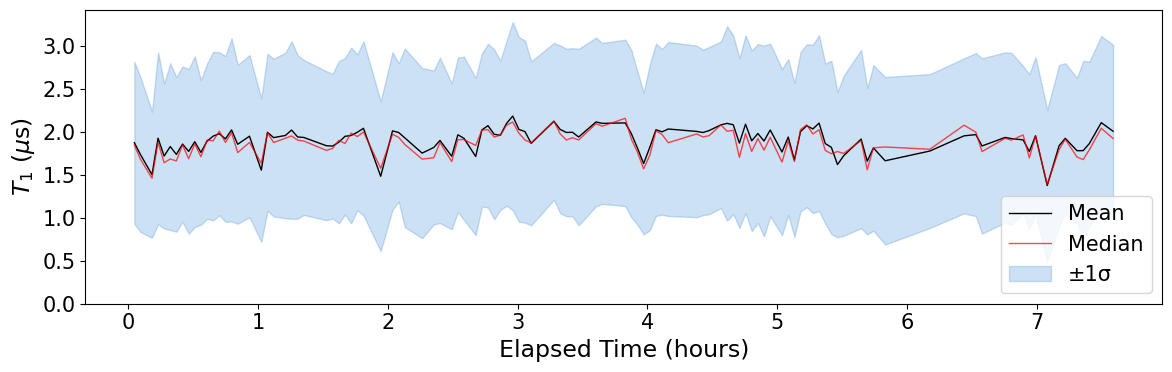

In [18]:
# Average T1 across all frequencies as a function of time
mean_t1_vs_time = np.nanmean(t1_list, axis=1)
median_t1_vs_time = np.nanmedian(t1_list, axis=1)
std_t1_vs_time = np.nanstd(t1_list, axis=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(timestamps, mean_t1_vs_time, "k-", lw=1, label="Mean")
ax.plot(timestamps, median_t1_vs_time, "r-", lw=1, alpha=0.7, label="Median")
ax.fill_between(timestamps, mean_t1_vs_time - std_t1_vs_time,
                mean_t1_vs_time + std_t1_vs_time, alpha=0.2, color="C0", label="\u00b11\u03c3")
ax.set_xlabel("Elapsed Time (hours)")
ax.set_ylabel("$T_1$ ($\\mu$s)")
ax.legend()
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()